In [1]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
#Step 2: Load Dataset
# Load dataset
df = pd.read_csv("1_boston_housing.csv")

# Remove quotes from column names (important for your dataset)
df.columns = df.columns.str.replace('"', '')

# Display first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
#Step 3: Split Features and Target
X = df.drop("MEDV", axis=1)   # Features
y = df["MEDV"]                # Target

print(X.shape, y.shape)

(506, 13) (506,)


In [4]:
#Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
#Step 5: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)

Epoch 1/100


c:\Users\vishw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 628.0941 - mae: 22.8405 - val_loss: 547.2091 - val_mae: 21.9430
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 626.3918 - mae: 22.8286 - val_loss: 547.0442 - val_mae: 21.9455
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 624.7299 - mae: 22.8169 - val_loss: 546.8802 - val_mae: 21.9481
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 623.0878 - mae: 22.8018 - val_loss: 546.7272 - val_mae: 21.9505
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 621.3995 - mae: 22.7880 - val_loss: 546.5444 - val_mae: 21.9516
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 619.8579 - mae: 22.7756 - val_loss: 546.3965 - val_mae: 21.9535
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 618.1862 - mae: 22.7606 - val_loss: 546.2397 - val_mae: 21.9545
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 616.6346 - mae: 22.7483 - val_loss: 546.0917 - val_mae: 21.9561
Epoch 9/100
12/12 ━━

In [7]:
#Step 6: Build Deep Neural Network
model = Sequential()

# Single neuron → behaves like linear regression
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\vishw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
#Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 605.9292 - mae: 22.9275 - val_loss: 554.4138 - val_mae: 22.2163
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 603.8376 - mae: 22.9107 - val_loss: 552.8873 - val_mae: 22.2005
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 601.6622 - mae: 22.8855 - val_loss: 551.4418 - val_mae: 22.1839
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 599.6036 - mae: 22.8628 - val_loss: 549.9084 - val_mae: 22.1674
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 597.3927 - mae: 22.8384 - val_loss: 548.5143 - val_mae: 22.1503
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 595.5103 - mae: 22.8184 - val_loss: 547.0728 - val_mae: 22.1335
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 593.5436 - mae: 22.7978 - val_loss: 545.6320 - val_mae: 22.1171
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 591.5326 - mae: 22.7744 - val_loss: 544.2913 - val_mae: 22.1004
Epoch 9/100
21/2

In [9]:
#Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 446.5509 - mae: 20.3445 
Test Loss (MSE): 446.5509338378906
Test MAE: 20.34446144104004


In [10]:
#Step 9: Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Actual: 23.60 | Predicted: 4.13
Actual: 32.40 | Predicted: 10.83
Actual: 13.60 | Predicted: -3.43
Actual: 22.80 | Predicted: 5.50
Actual: 16.10 | Predicted: -3.58


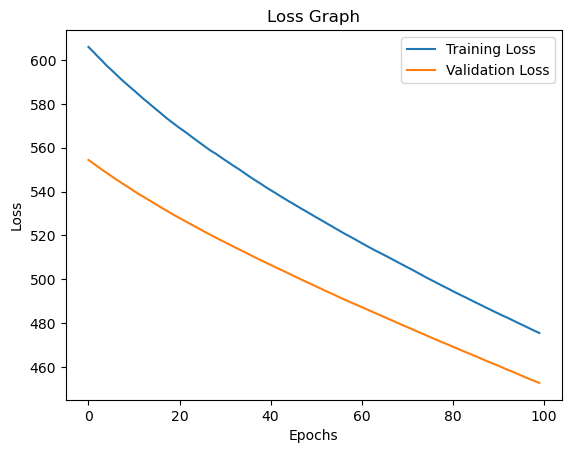

In [11]:
#Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()